In [322]:
import sqlite3
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect('../../krisha.kz/db.sqlite')
query = """
SELECT * FROM flats
JOIN prices ON flats.id = prices.flat_id
"""

df = pd.read_sql_query(query, conn)
conn.close()

df['specs'] = df['specs'].apply(json.loads)

# 2. Flatten the 'specs' column into a new DataFrame
specs_expanded = pd.json_normalize(df['specs'])

# 3. Join the new columns back to your original DataFrame
df = pd.concat([df.drop('specs', axis=1), specs_expanded], axis=1)
df.drop(columns=['id', 'photo', 'flat_id', 'star', 'focus', 'date'], inplace=True)
df = df.rename(columns={'type': 'internet', 'balcony_g': 'balcony_glazing'})
df['year'] = df['year'].astype(int)

df.columns.tolist()

df.describe(include='all')

# booleans: priv_dorm, furniture, has_change, balcony_glazing

,url,room,square,city,price,building,complex,year,floor,parking,...,toilet,balcony,door,internet,furniture,flooring,security,renovation,balcony_glazing,phone
count,7327,7327.000000,7327,7327,7.327000e+03,6953,5723,7327.000000,7109,4898,...,4614,3848,3250,2300,3701,3241,3291,3083,1938,1576
unique,7327,NaN,2669,1,NaN,4,944,NaN,378,3,...,3,4,3,4,3,7,139,5,2,4
top,https://krisha.kz/a/show/1009900178,NaN,90 м²,Астана,NaN,монолитный,Respublika,NaN,5 из 9,паркинг,...,2 с/у и более,лоджия,металлическая,оптика,полностью,ламинат,"домофон, видеонаблюдение",свежий ремонт,да,есть возможность подключения
freq,1,NaN,160,7327,NaN,3997,121,NaN,247,4443,...,2408,1603,2385,770,2590,2795,840,1595,1908,833
mean,NaN,3.005596,NaN,NaN,5.236750e+07,NaN,NaN,2015.919749,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.074600,NaN,NaN,1.801120e+07,NaN,NaN,11.370950,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,3.000000,NaN,NaN,1.050000e+07,NaN,NaN,1959.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,3.000000,NaN,NaN,3.900000e+07,NaN,NaN,2012.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.000000,NaN,NaN,4.990000e+07,NaN,NaN,2020.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.000000,NaN,NaN,6.450000e+07,NaN,NaN,2024.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [323]:
df.dropna(subset=['floor'], inplace=True)

df['current_floor'] = df['floor'].str.split().str[0]
df['total_floors'] = df['floor'].str.split().str[-1]

df['current_floor'] = pd.to_numeric(df['current_floor'], errors='coerce')
df['total_floors'] = pd.to_numeric(df['total_floors'], errors='coerce')

df['is_last_floor'] = df['current_floor'] == df['total_floors']
df['is_first_floor'] = df['current_floor'] == 1

print(df[['current_floor', 'is_last_floor', 'is_first_floor']].head(10))
df.head(5)

    current_floor  is_last_floor  is_first_floor
0              14           True           False
1               4          False           False
3               8          False           False
4               8          False           False
5               6          False           False
6               4          False           False
7              12          False           False
8              12           True           False
18              8          False           False
19              3          False           False


,url,room,square,city,price,building,complex,year,floor,parking,...,furniture,flooring,security,renovation,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor
0,https://krisha.kz/a/show/1009900178,3,88.6 м²,Астана,67800000,монолитный,Evolution,2025,14,паркинг,...,NaN,NaN,NaN,NaN,NaN,NaN,14,14,True,False
1,https://krisha.kz/a/show/1008564238,3,80 м²,Астана,50500000,кирпичный,Qazyna,2023,4 из 9,паркинг,...,NaN,NaN,NaN,NaN,NaN,NaN,4,9,False,False
3,https://krisha.kz/a/show/1007426712,3,84 м²,Астана,56000000,монолитный,Alan,2019,8 из 9,паркинг,...,полностью,ламинат,"домофон, видеонаблюдение",NaN,NaN,NaN,8,9,False,False
4,https://krisha.kz/a/show/1009267374,3,80 м²,Астана,59500000,кирпичный,GreenLine.Ару Кала,2021,8 из 9,паркинг,...,NaN,NaN,NaN,свежий ремонт,NaN,NaN,8,9,False,False
5,https://krisha.kz/a/show/1009495096,3,66.4 м²,Астана,33000000,монолитный,Sani Towers,2021,6 из 22,паркинг,...,NaN,NaN,NaN,NaN,NaN,NaN,6,22,False,False


In [324]:
df.dropna(subset=['square', 'ceiling'], inplace=True)
df['square_total'] = df['square'].str.split().str[0].astype(float)

df.dropna(subset=['ceiling'], inplace=True)
df['ceiling'] = df['ceiling'].str.split().str[0].astype(float)
df['ceiling'].head(10)



# df['square_kitchen'] = df['square'].str.split().str[-2].astype(float)
# df['square_kitchen'] = np.where(df['square_total'] == df['square_kitchen'], 
#                                 np.nan, 
#                                 df['square_kitchen'])
# print(df['square_kitchen'].isnull().sum())
# print(len(df['square_kitchen']))

0     3.00
1     2.70
3     3.00
4     3.00
5     2.70
6     2.70
7     3.00
8     2.70
18    2.75
19    3.10
Name: ceiling, dtype: float64

In [325]:
# Create a mapping dictionary
mapping = {'да': True, 'нет': False}

# Apply to your columns
df['priv_dorm'] = df['priv_dorm'].str.lower().map(mapping).astype('boolean')
df['has_change'] = df['has_change'].str.lower().map(mapping).astype('boolean')
df['balcony_glazing'] = df['balcony_glazing'].str.lower().map(mapping).astype('boolean')

df['balcony_glazing'] = df['balcony_glazing'].fillna(True)
df['priv_dorm'] = df['priv_dorm'].fillna(False)
df['has_change'].fillna(False)

# Check the results - NaNs stay as NaN
print(df[['priv_dorm', 'has_change', 'balcony_glazing']].value_counts(dropna=False))

print(df[['priv_dorm', 'has_change', 'balcony_glazing']])

priv_dorm  has_change  balcony_glazing
False      False       True               5887
           True        True                382
           False       False                27
True       False       True                  1
           True        True                  1
Name: count, dtype: int64
      priv_dorm  has_change  balcony_glazing
0         False       False             True
1         False       False             True
3         False        True             True
4         False       False             True
5         False       False             True
...         ...         ...              ...
7321      False       False             True
7323      False       False             True
7324      False       False             True
7325      False       False             True
7326      False       False             True

[6298 rows x 3 columns]


In [326]:
df['furniture'] = df['furniture'].fillna('не указан')

# 5. Verify the distribution is still similar to the original
print("New Value Counts (After Probabilistic Fill):")
print(df['furniture'].value_counts(normalize=True))
print(f"\nTotal NaNs remaining: {df['furniture'].isnull().sum()}")

New Value Counts (After Probabilistic Fill):
furniture
не указан     0.457764
полностью     0.379168
частично      0.132105
без мебели    0.030962
Name: proportion, dtype: float64

Total NaNs remaining: 0


In [327]:
print(df.nunique())

url                6298
room                  1
square             2424
city                  1
price               771
building              4
complex             930
year                 67
floor               373
parking               3
ceiling              39
priv_dorm             2
has_change            2
toilet                3
balcony               4
door                  3
internet              4
furniture             4
flooring              7
security            137
renovation            5
balcony_glazing       2
phone                 4
current_floor        31
total_floors         39
is_last_floor         2
is_first_floor        2
square_total        857
dtype: int64


In [328]:
print(df.dtypes)

url                    str
room                 int64
square                 str
city                   str
price                int64
building               str
complex                str
year                 int64
floor                  str
parking                str
ceiling            float64
priv_dorm          boolean
has_change         boolean
toilet                 str
balcony                str
door                   str
internet               str
furniture              str
flooring               str
security               str
renovation             str
balcony_glazing    boolean
phone                  str
current_floor        int64
total_floors         int64
is_last_floor         bool
is_first_floor        bool
square_total       float64
dtype: object


In [329]:
print(df['furniture'].value_counts(dropna=False))

furniture
не указан     2883
полностью     2388
частично       832
без мебели     195
Name: count, dtype: int64


In [330]:
print(df.describe())

         room         price         year      ceiling  current_floor  \
count  6298.0  6.298000e+03  6298.000000  6298.000000    6298.000000   
mean      3.0  5.337252e+07  2016.795808     2.881585       7.114322   
std       0.0  1.755098e+07    10.109951     0.470431       4.360696   
min       3.0  1.050000e+07  1961.000000     2.300000       1.000000   
25%       3.0  4.000000e+07  2013.000000     2.700000       4.000000   
50%       3.0  5.050000e+07  2020.000000     3.000000       6.000000   
75%       3.0  6.500000e+07  2024.000000     3.000000       9.000000   
max       3.0  1.000000e+08  2028.000000    28.000000      42.000000   

       total_floors  square_total  
count   6298.000000   6298.000000  
mean      11.868847     87.180352  
std        5.057046     18.720086  
min        1.000000     37.400000  
25%        9.000000     74.000000  
50%       10.000000     86.000000  
75%       14.000000     96.000000  
max       43.000000    215.000000  


In [331]:
# Select the columns you are analyzing
cols_to_check = [
    'price', 'square', 'year', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing'
]

# Count the NaNs for each
nan_counts = df[cols_to_check].isnull().sum()

# Display as a percentage to see the "damage"
nan_percentages = (df[cols_to_check].isnull().sum() / len(df)) * 100

# Combine them into a nice summary table
missing_data_summary = pd.DataFrame({
    'Total NaNs': nan_counts,
    'Percentage (%)': nan_percentages.round(2)
})

print(missing_data_summary.sort_values(by='Total NaNs', ascending=False))

                 Total NaNs  Percentage (%)
price                     0             0.0
square                    0             0.0
year                      0             0.0
current_floor             0             0.0
total_floors              0             0.0
is_last_floor             0             0.0
is_first_floor            0             0.0
priv_dorm                 0             0.0
has_change                0             0.0
balcony_glazing           0             0.0


Text(0.5, 1.0, 'Correlation Heatmap: Apartment Features')

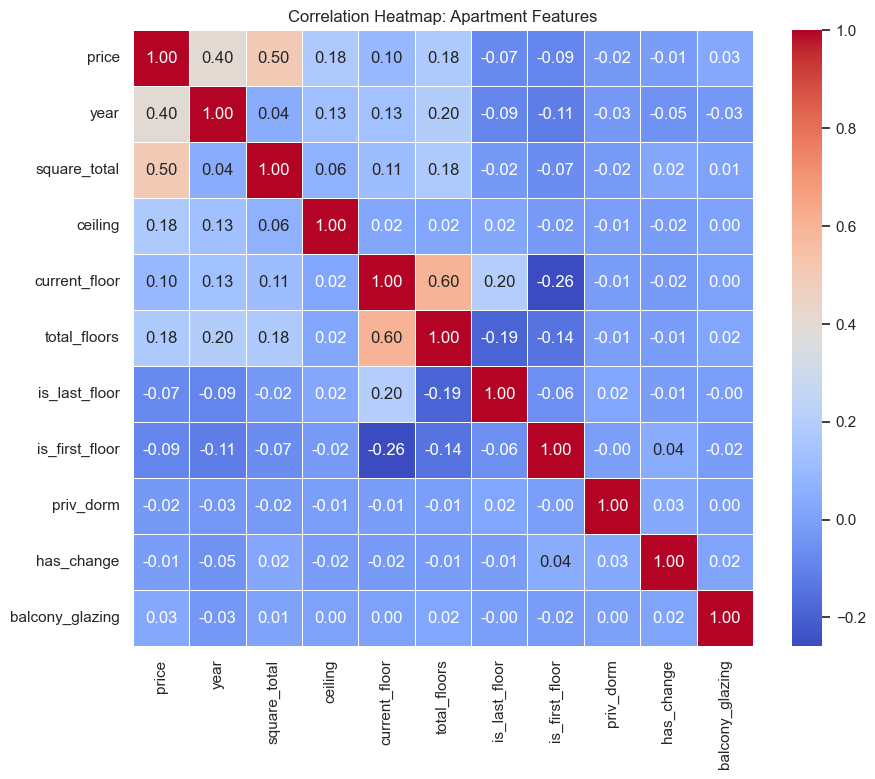

In [332]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numeric and boolean columns we created
# (Assuming your target column is named 'price')
cols_to_plot = [
    'price', 'year', 'square_total', 'ceiling', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing',
]

# 2. Calculate the correlation matrix
# Only include columns that actually exist in your df
existing_cols = [c for c in cols_to_plot if c in df.columns]
corr_matrix = df[existing_cols].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the numbers in the boxes
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5       # Add thin lines between boxes
)

plt.title('Correlation Heatmap: Apartment Features')

In [333]:
df[[
    'price', 'year', 'square_total', 'ceiling', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing',
]].isnull().sum()

price              0
year               0
square_total       0
ceiling            0
current_floor      0
total_floors       0
is_last_floor      0
is_first_floor     0
priv_dorm          0
has_change         0
balcony_glazing    0
dtype: int64

In [334]:
df['renovation'] = df['renovation'].fillna('не указан')

# Quick check of the new landscape
print("Renovation distribution after filling:")
print(df['renovation'].value_counts())

Renovation distribution after filling:
renovation
не указан                         3473
свежий ремонт                     1480
не новый, но аккуратный ремонт     879
черновая отделка                   359
требует ремонта                     93
свободная планировка                14
Name: count, dtype: int64


In [335]:
df[[
 'building',
 'complex',
 'parking',
 'toilet',
 'balcony',
 'door',
 'internet',
 'furniture',
 'flooring',
 'security',
 'renovation',
 'balcony_glazing',
 'phone',
 'current_floor',
 'total_floors',
 'is_last_floor',
 'is_first_floor',
 'square_total']].isnull().sum()

building            189
complex             962
parking            1609
toilet             2197
balcony            2759
door               3304
internet           4137
furniture             0
flooring           3287
security           3235
renovation            0
balcony_glazing       0
phone              4819
current_floor         0
total_floors          0
is_last_floor         0
is_first_floor        0
square_total          0
dtype: int64

In [337]:
# --- CELL: Categorical Impact on Price (Box Plots) ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the list of categorical columns you want to analyze
categorical_cols = [
    'year'
    'building',
    'parking',
    'toilet',
    'balcony',
    'door',
    'internet',
    'furniture',
    'flooring',
    'security',
    'renovation',
    'balcony_glazing',
    'phone',
    'is_last_floor',
    'is_first_floor',
]

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")

# 3. Loop through the list and create a plot for each
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    
    # Create the boxplot
    # Note: We use showfliers=False if the outliers (extreme prices) squash the boxes
    sns.boxplot(x=col, y='price', data=df, palette='viridis', showfliers=False)
    
    plt.title(f'Influence of {col} on Price', fontsize=15)
    plt.xticks(rotation=45)
    plt.ylabel('Price')
    plt.xlabel(col.capitalize())
    
    plt.show()

ValueError: Could not interpret value `yearbuilding` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>